## This Notebook gives an example on how to plot the quality control plots for MERFISH cell clustering (Figure 1 in the manuscript)

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import zscore
import numpy as np
from scipy.stats import ttest_1samp
import seaborn as sns
from adjustText import adjust_text
from scipy.stats import pearsonr

In [2]:
#### PLOT GENE
# Function to plot gene expression across single cells in X_spatial

def plot_gene_scdata(scdata2,gene='SOX9',nmax=20,sz_min=5,sz_max=30,transpose=1,flipx=1,flipy=1,tag='X_spatial'):
    import matplotlib.pyplot as plt
    fig = plt.figure(figsize=(15, 15), facecolor="white")
    Xcells = scdata2.obsm[tag][:,::transpose]*[flipx,flipy]
    ign = list(scdata2.var.index).index(gene)
    if 'X_raw' not in scdata2.obsm:
        Xnorm = (np.exp(scdata2.X)-1)
        ncts = np.sum(Xnorm,axis=1)[0]
        scdata2.obsm['X_raw']=np.round(Xnorm/ncts*np.array(scdata2.obs['total_counts'])[:,np.newaxis])
    cts = scdata2.obsm['X_raw'][:,ign].copy()
    plt.style.use("default")
    cts[np.isnan(cts)]=0
    #cts[cts>20]=0
    ncts = np.clip(cts/nmax,0,1)
    size = sz_min+ncts*(sz_max-sz_min)
    from matplotlib import cm as cmap
    cols = cmap.coolwarm(ncts)

    good_cells = slice(None)
    good_cells = np.argsort(cts)

    XC = -Xcells[good_cells,::-1]
    fig = plt.figure(facecolor='k')
    plt.title(gene+' - N max '+str(nmax))
    fig.set_facecolor('white')
    plt.scatter(XC[:,0],XC[:,1],c=cols[good_cells],s=size[good_cells])
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.axis("equal")

    return fig

In [3]:
###PLOT CLUSTER NAME
# Function to plot cell-types across single cells in X_spatial

def plot_cluster_name_scdata(scdata,cmap,clusters=['Neuron','Astro'],transpose=1,flipx=1,flipy=1,sbig=30,small=5):
    import matplotlib.pyplot as plt
    fig = plt.figure(figsize=(40, 40), facecolor="white")

    from matplotlib import pylab as plt
    x,y = (scdata.obsm['X_spatial']*[-flipx,-flipy])[:,::-transpose].T
    
    plt.scatter(x, y, c='gray', s=small, marker='.')
    i=0
    for cluster in clusters:
        cluster_ = str(cluster)
        inds = scdata.obs["cluster_names"] == cluster_
        x_ = x[inds]
        y_ = y[inds]
        col = cmap[int(i) % len(cmap)]
        i=i+1
        plt.scatter(x_, y_, c=col, s=sbig, marker='.',label = cluster_)
    
    plt.grid(False)
    plt.axis("off")
    plt.axis("equal")
    plt.legend()
    plt.tight_layout()
    return fig

In [4]:
C4 = sc.read_h5ad('adata/Dryad/C4_ref.h5ad')

In [5]:
#######################################
#### FIGURE 1D: UMAP
#######################################

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:371: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:381: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cma

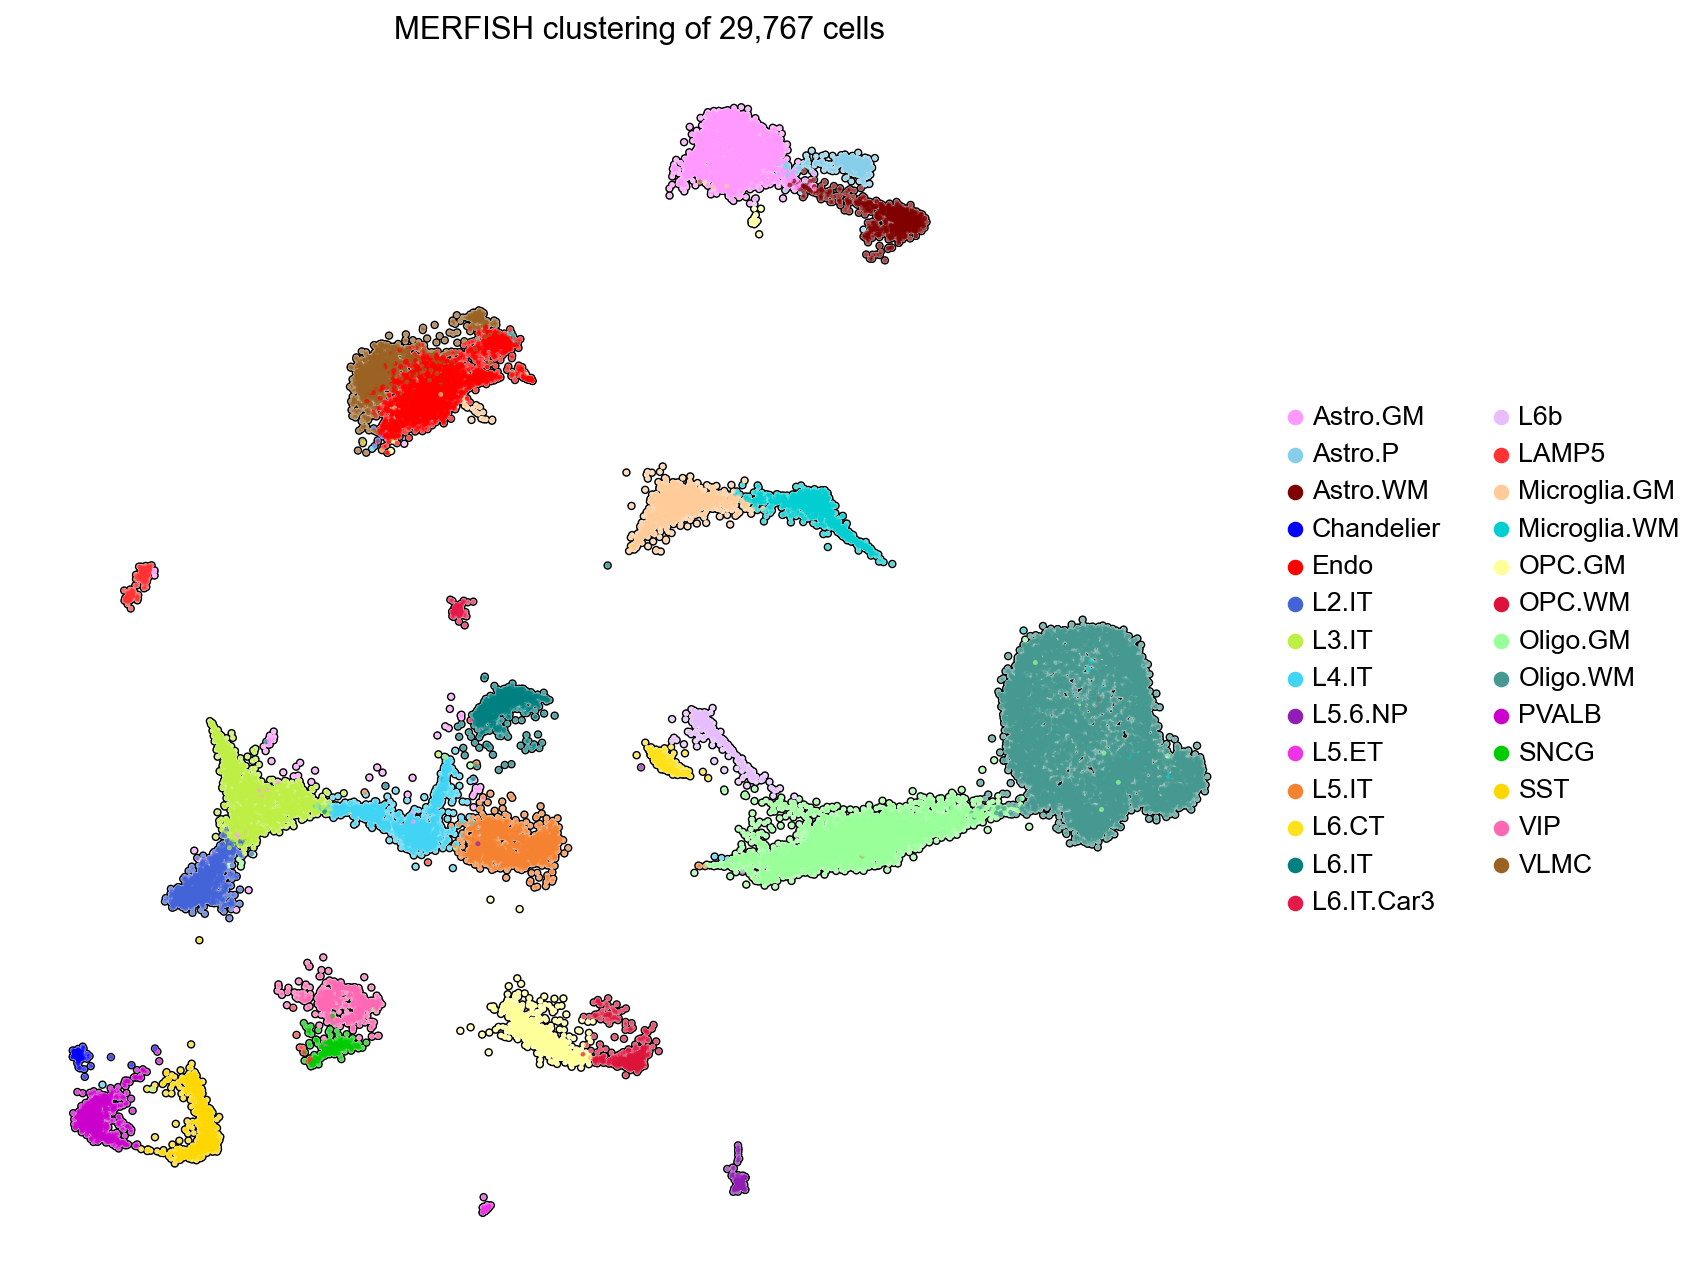

In [6]:
cmap = [
    '#ff99ff', '#87CEEB', '#800000', #Astro GM, P, WM
    '#0000ff', #Chandelier
    '#FF0000', #Endo
    '#4363d8', '#bfef45', #L2, L3, 
    '#42d4f4',  # L4
    '#911eb4', '#f032e6','#f58231', #L56NP, L5ET, L5
    '#ffe119',  '#008080', '#e6194B', '#e6beff', #L6CT, L6, L6Car3, L6b
    '#ff3333', #LAMP5
    '#ffcc99',  '#00CED1',  '#ffff99','#DC143C', #Microglia GM, WM, OPC GM, WM
    '#99ff99', '#469990',  #Oligo GM, WM
    '#cc00cc', #PVALB
    '#00cc00','#FFD700',   '#FF69B4', #SNCG, SST, VIP
    '#9A6324', #VLMC     
]

plt.style.use('default')
sc.set_figure_params(figsize=(10,10))
fig = sc.pl.umap(
    C4,
    color="cluster_names",
    add_outline=True,
    #legend_loc="on data",
    size=20,
    legend_fontsize=12,
    legend_fontoutline=1,
    frameon=False,
    title=f"MERFISH clustering of {len(C4):,d} cells",
    palette=cmap,return_fig=True
)
plt.savefig('Figures/F1D.png', dpi=300, bbox_inches='tight')

In [7]:
#######################################
#### FIGURE 1E: Heatmap Cell-type correlation MERFISH vs ABA PFC
#######################################

In [8]:
merged_dt=pd.read_csv('/Users/Olatz/BintuLabScripts/SEAAD_PFC/SEAAD_PFC_mean_expression.csv')

In [9]:
merged_dt =merged_dt[merged_dt['gene'].isin(C4.var_names)]

In [10]:
merged_dt

,gene,L6b,L6 IT,L6 IT Car3,OPC,Pvalb,L6 CT,L5/6 NP,Sst,L2/3 IT,...,Sncg,Endothelial,Microglia-PVM,Astrocyte,Lamp5,Oligodendrocyte,Pax6,L5 ET,Sst Chodl,VLMC
30,ISG15,0.013083,0.007570,0.034394,0.042803,0.049188,0.004097,0.009262,0.055686,0.019129,...,0.067353,0.299029,0.009988,0.033527,0.063799,0.003588,0.072023,0.034967,0.045354,0.217659
55,CPTP,0.038441,0.035800,0.025756,0.023961,0.044465,0.027629,0.048134,0.033415,0.037562,...,0.043885,0.110096,0.011782,0.019274,0.051048,0.015571,0.063193,0.042518,0.043990,0.033254
216,RERE,1.471946,1.716137,1.572108,1.821642,1.769492,1.634187,1.481949,1.708741,1.598591,...,1.885160,1.797929,1.916187,1.598139,1.919576,2.045840,1.826158,1.567445,1.831173,1.329892
233,TMEM201,0.060386,0.057167,0.042682,0.067856,0.077229,0.052925,0.054180,0.075669,0.046400,...,0.049612,0.036648,0.026443,0.032423,0.086374,0.028895,0.103068,0.046098,0.056431,0.050117
234,PIK3CD,0.097237,0.087836,0.080102,0.034732,0.138442,0.028240,0.135277,0.253796,0.043368,...,0.042639,0.037555,0.655623,0.026202,0.098050,0.008967,0.055109,0.102017,0.250705,0.858194
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36079,IL13RA1,0.001664,0.002482,0.003288,0.003471,0.002869,0.001619,0.002760,0.002941,0.002004,...,0.005710,0.684469,0.862631,0.005552,0.016989,0.021242,0.015687,0.003313,0.000000,0.242648
36082,LONRF3,0.012400,0.004583,0.008246,0.019713,0.012734,0.001502,0.003344,0.038550,0.015132,...,0.188567,0.032614,0.006620,0.082498,0.150600,0.002592,0.094701,0.000855,0.002927,0.024190
36137,XIAP,0.285215,0.293543,0.304302,0.247710,0.309943,0.268611,0.356951,0.309931,0.289437,...,0.314985,0.325730,0.253041,0.276473,0.383126,0.244127,0.356826,0.246021,0.362275,0.268592
36350,CETN2,0.029235,0.038221,0.030504,0.009721,0.023303,0.034110,0.040674,0.028441,0.039683,...,0.017542,0.028127,0.012166,0.018297,0.035289,0.007040,0.031755,0.041598,0.036502,0.005210


In [11]:
merged_dt = merged_dt.set_index('gene')

In [12]:
merged_dt.keys()

Index(['L6b', 'L6 IT', 'L6 IT Car3', 'OPC', 'Pvalb', 'L6 CT', 'L5/6 NP', 'Sst',
       'L2/3 IT', 'Lamp5 Lhx6', 'L4 IT', 'L5 IT', 'Vip', 'Chandelier', 'Sncg',
       'Endothelial', 'Microglia-PVM', 'Astrocyte', 'Lamp5', 'Oligodendrocyte',
       'Pax6', 'L5 ET', 'Sst Chodl', 'VLMC'],
      dtype='object')

In [13]:
names_seq= ['L2/3 IT','L4 IT', 'L5 IT','L5 ET', 'L5/6 NP', 'L6 IT', 'L6 IT Car3','L6 CT','L6b','Lamp5', 'Lamp5 Lhx6','Pax6',  'Sncg','Vip','Sst','Sst Chodl','Pvalb', 'Chandelier',
            'Astrocyte','OPC',  'Oligodendrocyte', 'Endothelial','VLMC','Microglia-PVM' ]

In [14]:
merged_dt = merged_dt[names_seq]

In [15]:
M_adata=sc.read_h5ad('adata/Dryad/adata_AGG_CAG.h5ad')

<function matplotlib.pyplot.show(close=None, block=None)>

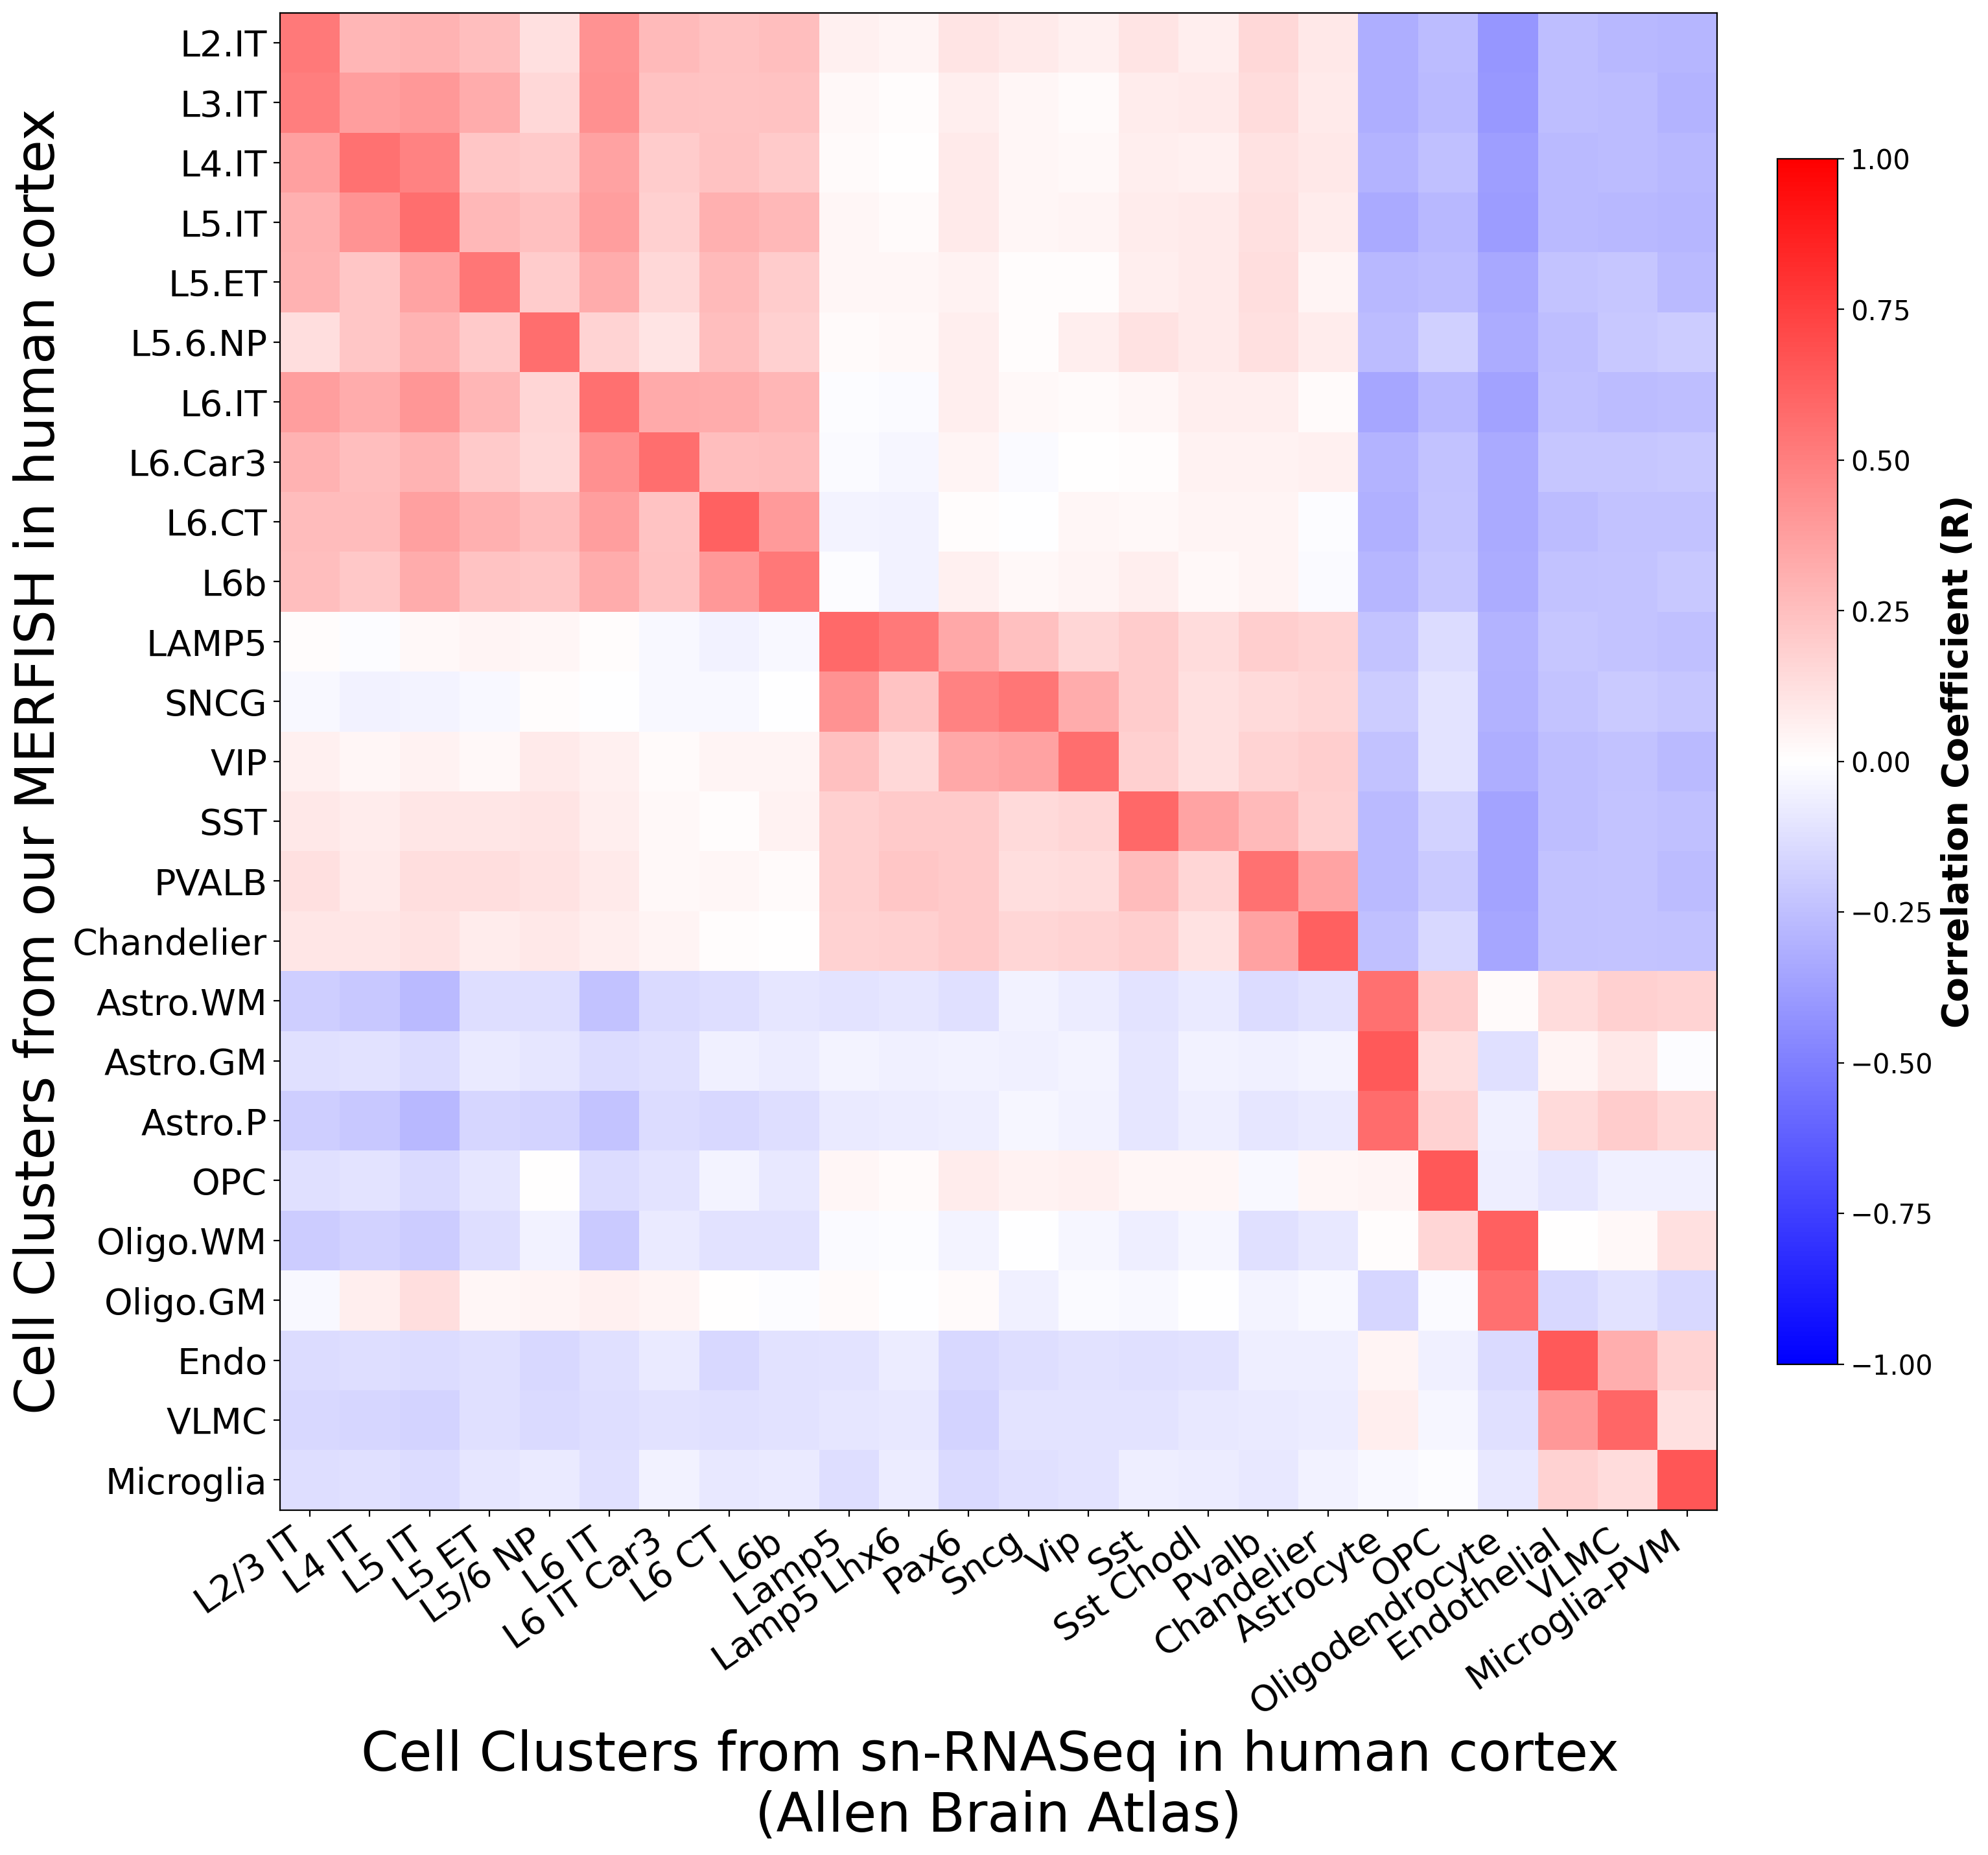

In [16]:
cluster_order = ["L2.IT", "L3.IT","L4.IT",'L5.IT', 'L5.ET', "L5.6.NP",'L6.IT','L6.Car3', "L6.CT",'L6b',"LAMP5", "SNCG",'VIP', "SST", "PVALB","Chandelier", "Astro.WM", 'Astro.GM','Astro.P', 'OPC',  'Oligo.WM', 'Oligo.GM','Endo', 'VLMC','Microglia']
M_adata_s = M_adata[:,merged_dt.index]

X_MERFISH_zscored = zscore(M_adata_s.X,axis=0)
clusters = M_adata_s.obs['cluster_names']
X_MERFISH_zscored_per_cluster = np.array([np.mean(X_MERFISH_zscored[cl==clusters],axis=0) for cl in cluster_order])

X_seq = np.array(merged_dt.iloc[:,:]).T
X_seq[np.isnan(X_seq)]=0
X_seq_zscored = zscore(X_seq,axis=0)
X_seq_zscored[np.isnan(X_seq_zscored)]=0

Mcor = [[np.corrcoef(clMER,clSEQ)[0,1] for clSEQ in X_seq_zscored] for clMER in X_MERFISH_zscored_per_cluster]
xnames = list(merged_dt.keys())
dic_rename = dict(zip(M_adata_s.obs['leiden'],M_adata_s.obs['cluster_names']))

plt.style.use('default')
plt.figure(figsize=(30,15))
im = plt.imshow(Mcor,cmap='bwr', vmin=-1, vmax=1)
cbar = plt.colorbar(im, fraction=0.02, pad=0.02)
cbar.set_label('Correlation Coefficient (R)', fontsize=20, fontweight='bold')
cbar.ax.tick_params(labelsize=15)
plt.xticks(np.arange(len(xnames)),xnames,rotation=35,ha='right',size=20);
plt.yticks(np.arange(len(cluster_order)),cluster_order,size=20)
plt.ylabel('Cell Clusters from our MERFISH in human cortex', size=30)
plt.xlabel('Cell Clusters from sn-RNASeq in human cortex \n(Allen Brain Atlas)', size=30)
plt.savefig('Figures/F1E.png', dpi=300, bbox_inches='tight')
plt.show

In [17]:
Mcor = np.array(Mcor)

max_r = Mcor.max(axis=1)
max_idx = Mcor.argmax(axis=1)
max_allen_clusters = [xnames[i] for i in max_idx]

results_df = pd.DataFrame({
    'MERFISH_cluster': cluster_order,
    'Max_correlation': max_r,
    'Best_matching_Allen_cluster': max_allen_clusters
})

mean_corr = np.mean(max_r)
std_corr = np.std(max_r)

t_stat, p_val = ttest_1samp(max_r.flatten(), 0)

print("===== Summary =====")
print(f"Mean correlation (all pairs): {mean_corr:.3f} ± {std_corr:.3f}")
print(f"T-test p-value (r > 0): {p_val:.5f}")
print(f"T-stat: {t_stat:.5f}")
print()
print("===== Per-MERFISH Cluster Max Correlation =====")
print(results_df)
results_df.to_csv('stats_F1E.csv')

===== Summary =====
Mean correlation (all pairs): 0.578 ± 0.042
T-test p-value (r > 0): 0.00000
T-stat: 67.37841

===== Per-MERFISH Cluster Max Correlation =====
   MERFISH_cluster  Max_correlation Best_matching_Allen_cluster
0            L2.IT         0.517567                     L2/3 IT
1            L3.IT         0.507019                     L2/3 IT
2            L4.IT         0.548518                       L4 IT
3            L5.IT         0.564233                       L5 IT
4            L5.ET         0.535632                       L5 ET
5          L5.6.NP         0.563072                     L5/6 NP
6            L6.IT         0.558496                       L6 IT
7          L6.Car3         0.567208                  L6 IT Car3
8            L6.CT         0.612224                       L6 CT
9              L6b         0.526950                         L6b
10           LAMP5         0.583457                       Lamp5
11            SNCG         0.538836                        Sncg
12    

In [18]:
#######################################
#### FIGURE 1D: HTT expression Correlation MERFISH vs ABA PFC
#######################################

In [19]:
counts = sc.read_h5ad('../../SEAAD_PFC/SEAAD_A9_RNAseq_final-nuclei.2024-02-13.h5ad')

In [20]:
counts.obs['Neurotypical reference'] = counts.obs['Neurotypical reference'].astype(str).map({'True': True, 'False': False})

In [21]:
counts.obs['Neurotypical reference'].unique()

array([False,  True])

In [22]:
ABA_CTL=counts[counts.obs['Neurotypical reference']==True].copy()

In [23]:
M_CTL=M_adata[M_adata.obs['HD']==False].copy()

In [24]:
# Match cluster names
cluster_map = {
    'L2.IT': 'L2/3 IT',
    'L3.IT': 'L2/3 IT',
    'L4.IT': 'L4 IT',
    'L5.IT': 'L5 IT',
    'L5.ET': 'L5 ET',
    'L5.6.NP': 'L5/6 NP',
    'L6.IT': 'L6 IT',
    'L6.Car3': 'L6 IT Car3',
    'L6.CT': 'L6 CT',
    'L6b': 'L6b',
    'SST': 'Sst',
    'PVALB': 'Pvalb',
    'VIP': 'Vip',
    'LAMP5': 'Lamp5',
    'Chandelier': 'Chandelier',
    'SNCG': 'Sncg',
    'Astro.P': 'Astrocyte', 
    'Astro.WM': 'Astrocyte', 
    'Astro.GM': 'Astrocyte',
    'Oligo.WM': 'Oligodendrocyte',
    'Oligo.GM': 'Oligodendrocyte',
    'OPC': 'OPC',
    'Endo': 'Endothelial',
    'VLMC': 'VLMC',
    'Microglia': 'Microglia-PVM',
}

In [25]:
# Remap cluster names for M_CTL
M_CTL.obs['mapped_cluster'] = M_CTL.obs['cluster_names'].map(cluster_map).fillna(M_CTL.obs['cluster_names'])

In [26]:
# RAW COUNTS
gene_idx = M_CTL.var.index.get_loc('HTT')
htt_expr = M_CTL.obsm['X_raw'][:, gene_idx]

m_expr = (
    pd.DataFrame(
        htt_expr,
        index=M_CTL.obs['mapped_cluster'],
        columns=['HTT']
    )
    .groupby(level=0)
    .mean()
)

gene_idx_ctl = ABA_CTL.var.index.get_loc('HTT')

aba_raw = ABA_CTL.layers['UMIs'][:, gene_idx_ctl]

if hasattr(aba_raw, "toarray"):
    aba_raw = aba_raw.toarray()

aba_raw = aba_raw.flatten().astype(float)
aba_expr = (
    pd.DataFrame(
        aba_raw,
        index=ABA_CTL.obs['Subclass'],
        columns=['HTT']
    )
    .groupby(level=0)
    .mean()
)

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_93016/1843359369.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.DataFrame(


In [27]:
common_clusters = m_expr.index.intersection(aba_expr.index)

m_expr = m_expr.loc[common_clusters]
aba_expr = aba_expr.loc[common_clusters]

rho, pval = pearsonr(m_expr.squeeze().values,aba_expr.squeeze().values)
print(f"Pearson correlation for HTT across clusters: {rho:.2f} (p={pval:.3e})")

Pearson correlation for HTT across clusters: 0.96 (p=1.409e-11)


/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/matplotlib/text.py:894: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/matplotlib/text.py:895: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/matplotlib/text.py:753: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/matplotlib/text.py:754: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeErr

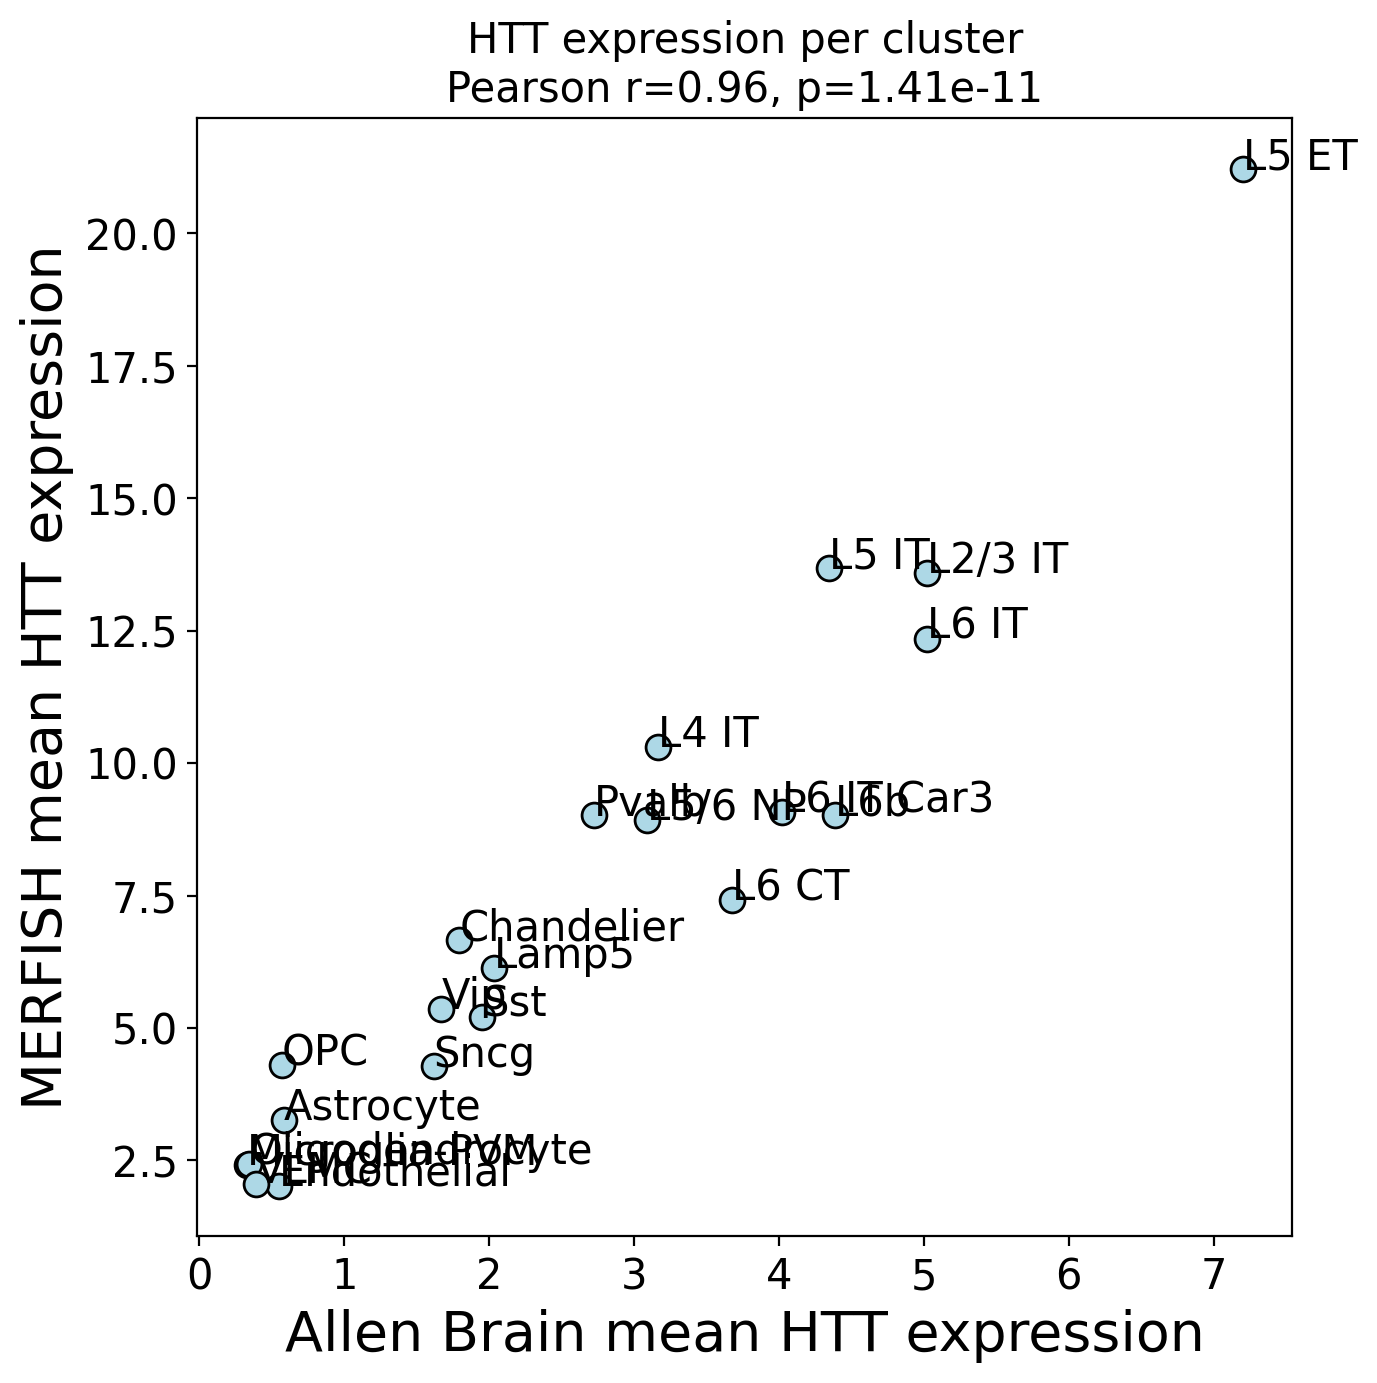

In [28]:
plt.figure(figsize=(7,7))
plt.scatter(
    aba_expr.values,
    m_expr.values,
    c='lightblue',
    s=80,
    edgecolor='black'
)

texts = []
for c in aba_expr.index:
    texts.append(
        plt.text(
            aba_expr.loc[c],
            m_expr.loc[c],
            c,
            fontsize=15
        )
    )

#adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black'))

plt.ylabel('MERFISH mean HTT expression', size=20)
plt.xlabel('Allen Brain mean HTT expression', size=20)
plt.title(f'HTT expression per cluster\nPearson r={rho:.2f}, p={pval:.2e}', size=15)
plt.xticks(size=15)
plt.yticks(size=15)
plt.tight_layout()
plt.savefig('Figures/F1F.png', dpi=300, bbox_inches='tight')
plt.show()
